# Donut Transition

In [1]:
import sys
sys.path.insert(0, '../../src/')

import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl
import tensorflow as tf

from spectrum import channel_spectrum, complex_spacing_ratio, Spectrum, coat_spectrum
from utils import saver

#np.set_printoptions(threshold=sys.maxsize)
np.set_printoptions(precision=4)

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

2025-10-30 14:55:15.135239: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def model_to_csr(model_list):
    spectrum_list = []
    csr_integrable_list = []
    for model in model_list:
        channel = model.channel
        spectrum = channel_spectrum(channel)

        csr = complex_spacing_ratio(spectrum)

        spectrum_list.append(spectrum)
        csr_integrable_list.append(csr)

    return csr_integrable_list

## Book keeping Super Operators

Create directories, then run the following cells to book keep all the super operators

In [12]:
model_list1 = pkl.load(open(f'../fitting_maps/models/integrable_model_4_L=5.model', 'rb'))
model_list2 = pkl.load(open(f'../fitting_maps/models/integrable_model_4_L=10.model', 'rb'))
model_list3 = pkl.load(open(f'../fitting_maps/models/integrable_model_4_L=20_reorder.model', 'rb'))
model_list4 = pkl.load(open(f'../fitting_maps/models/integrable_model_4_L=30_reorder.model', 'rb'))
model_list5 = pkl.load(open(f'../fitting_maps/models/integrable_model_4_L=40_reorder.model', 'rb'))
model_list6 = pkl.load(open(f'../fitting_maps/models/integrable_model_4_L=50_reorder.model', 'rb'))

In [13]:
for i, model in enumerate(model_list1):
    SO = model.channel.superoperator
    saver(SO, f"bookkeeping/superoperators_4q_ff/layers5/superoperator{i}")

In [14]:
for i, model in enumerate(model_list2):
    SO = model.channel.superoperator
    saver(SO, f"bookkeeping/superoperators_4q_ff/layers10/superoperator{i}")

In [15]:
for i, model in enumerate(model_list3):
    SO = model.channel.superoperator
    saver(SO, f"bookkeeping/superoperators_4q_ff/layers20/superoperator{i}")

In [ ]:
for i, model in enumerate(model_list4):
    SO = model.channel.superoperator
    saver(SO, f"bookkeeping/superoperators_4q_ff/layers30/superoperator{i}")

In [17]:
for i, model in enumerate(model_list5):
    SO = model.channel.superoperator
    saver(SO, f"bookkeeping/superoperators_4q_ff/layers40/superoperator{i}")

In [18]:
for i, model in enumerate(model_list6):
    SO = model.channel.superoperator
    saver(SO, f"bookkeeping/superoperators_4q_ff/layers50/superoperator{i}")

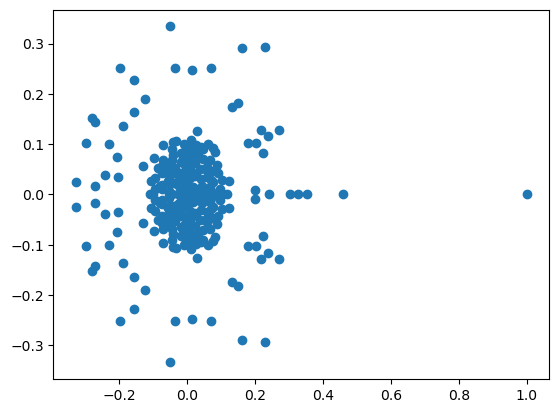

In [19]:
eig,_ = np.linalg.eig(SO)
plt.plot(eig.real, eig.imag, "o")

## Additional L=5 Integrable

In [21]:
model_list1 = pkl.load(open(f'../baseline_comparison/models/integrable_model_4_L=5.model', 'rb'))

In [22]:
for i, model in enumerate(model_list1):
    SO = model.channel.superoperator.numpy()
    #presision float64
    np.savetxt(f"bookkeeping/superoperators_4q_ff/layers5_additional/superoperator{i}.txt", SO, fmt='%.16f')
    #saver(SO, f"bookkeeping/superoperators_4q_ff/layers5_additional/superoperator{i}")

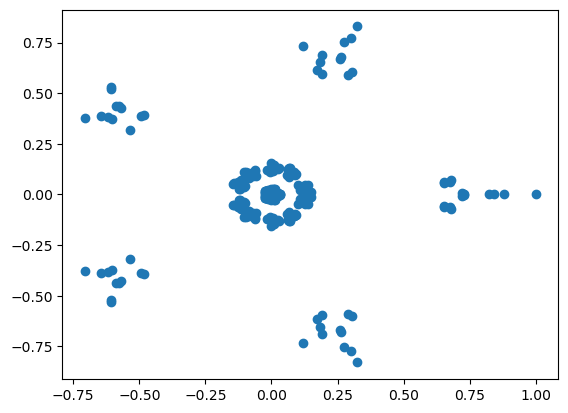

In [23]:
eig,_ = np.linalg.eig(SO)
plt.plot(eig.real, eig.imag, "o")

In [32]:
csr_list = []
for model in model_list1:
    channel = model.channel
    spectrum = channel_spectrum(channel)

    csr = complex_spacing_ratio(spectrum)

    csr_list.append(csr)

In [33]:
csr = Spectrum(csr_list)

In [37]:
from spectrum import spectrum_to_angular, spectrum_to_radial
from analysis import model_to_csr, scatterplot_stats

radial = spectrum_to_radial(csr)
angular = spectrum_to_angular(csr)

In [38]:
r, a = scatterplot_stats(radial, angular)

In [39]:
print(r, a)

0.6534753750194977 -0.16447691470228984
